# Smart Charging Using Reinforcement Learning

Approach for RL: an electric taxi is home from 2pm to 4pm each day. Every 15 minutes the charging agent picks a charging power (discrete levels between 0 and 22 kW). The battery can't exceed its capacity. When the taxi leaves at 4pm, a random energy demand for the day (D ~ N(30, 5) kWh) is drawn and must be covered by the battery, otherwise we pay a very high penalty. Charging cost grows with the square of the charging power. We model this as an MDP and solve it with Q-learning.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict

## MDP Definition

- **State s** = (t, b): the current 15-minute timestep $t \in \{0, ..., 7\}$ (2pm to 4pm)
  and the current battery level b, discretized into bins so we can use a Q-table.
- **Action a**: one of 4 discrete charging power levels (zero / low / medium / high).
- **Transition**: battery increases by power * 0.25h, capped at battery capacity.
- **Reward**: negative charging cost each step (cost = coef * power^2). At the final step, we additionally subtract a large penalty if the battery is below the sampled demand.

**Assumptions**:
- **Battery capacity: 60 kWh**
According to https://www.kaiyiglobal.com/blog/best-ev-for-taxi-in-2026-top-5-electric-cars-for-taxi-drivers Tesla Model Y is one for the most used models for EV taxis in North America and according to https://ev-database.org/cheatsheet/useable-battery-capacity-electric-car the battery capacity of EVs is 60 kWh.

- **Charging levels: 0, 7, 14, 22 kW**
According to https://podenergy.com/guides/how-long-to-charge-an-electric-car fast chargers go up to 22kW which is enough to charge the Tesla Model Y.

- Starting battery level at 2pm: random between 5 and 20 kWh (car arrives partially depleted)

- **Cost coefficient: 0.095 - 0.166**
According to https://www.blacklane.com/en/blog/travel/rush-hour-in-chicago/ 2pm to 4pm is Off-peak-hour, also since there are many ev charging sites in [Chicago](https://chargefinder.com/en/chicago/charging-station/q7krpr) we assume the state of off peak, public charging. This can be intrepreted according to https://www.beechargedev.com/mobile-ev-charging-cost-in-chicago-il/ to be Public Level 2 EV Charging which responds to $0.20 to $0.35 per kWh. <br>
At medium power (action=2, 14 kW, so 3.5 kWh per step): <br>
Cheap end ($0.20/kWh): α = 0.20 × 3.5 / e² ≈ **0.095** <br>
Expensive end ($0.35/kWh): α = 0.35 × 3.5 / e² ≈ **0.166** <br>
The difference between each step should be same: <br>
Difference: (0.166 - 0.095) / 8 ≈ 0.009 <br>

In [2]:
# Environment settings
NUM_STEPS = 8                    # 15-min steps between 2pm and 4pm
STEP_HOURS = 0.25                # each step is 0.25 hours
BATTERY_CAPACITY = 60.0          # max kWh the battery can hold
CHARGE_LEVELS = [0, 7, 14, 22]   # kW, discrete actions (zero/low/medium/high)
BATTERY_BIN_SIZE = 1.0           # we round battery to 1 kWh bins for the Q-table

# cost = COST_COEFFS * power_kw**2 per step
# Time-varying cost coefficients (one per 15-min step, cheapest early)
COST_COEFFS = [0.095, 0.104, 0.113, 0.122, 0.131, 0.140, 0.149, 0.160]

DEMAND_MEAN = 30.0
DEMAND_STD = 5.0
OUT_OF_ENERGY_PENALTY = 1000.0

START_BATTERY_LOW = 5.0
START_BATTERY_HIGH = 20.0

Calculate the normal distribution's mean and standard deviation based on the provided taxi data to get a realistic simulation

In [3]:
# Load raw trip data (adjust path to your actual file)
trips = pd.read_parquet("../data/processed_data/gold_taxi.parquet")

trips

,trip_id,taxi_id,trip_start_timestamp,trip_end_timestamp,trip_seconds,trip_miles,pickup_census_tract,dropoff_census_tract,pickup_community_area,dropoff_community_area,...,payment_type,company,pickup_centroid_latitude,pickup_centroid_longitude,pickup_centroid_location,dropoff_centroid_latitude,dropoff_centroid_longitude,dropoff_centroid_location,pickup_from_census_tract,pickup_h3_cell
0,85b4a91132f8b2d2d7fef4289ceb16d845dd7e51,1e17dd9f6bce9b805ec3f6c6b510caa5a64e4b67e9f3b7...,2026-04-03 12:45:00,2026-04-03 12:45:00,414,3.28,1.703198e+10,1.703177e+10,76,NaN,...,Mobile,City Service,41.979071,-87.903040,POINT (-87.9030396611 41.9790708201),41.982775,-87.877305,POINT (-87.8773053996 41.9827750091),1,88275934edfffff
1,8567fa2122d7e14ae2a7b7fc38f03357e8a4a3fa,d693b8f94b07db18f4ef688d9d9cd2d55cbf5c3313971d...,2026-04-03 12:45:00,2026-04-03 13:15:00,2215,17.80,1.703198e+10,1.703108e+10,76,8.0,...,Mobile,Chicago Independents,41.979071,-87.903040,POINT (-87.9030396611 41.9790708201),41.899156,-87.626211,POINT (-87.6262105324 41.8991556134),1,88275934edfffff
2,fac1a7c239b159c6a281c58d4ffcb7799a40a6e5,6e6b305564917024d22c3818670644f3ac4a45fd200490...,2026-04-03 12:45:00,2026-04-03 13:30:00,2160,12.80,NaN,NaN,56,31.0,...,Cash,Transit Administrative Center Inc,41.792592,-87.769615,POINT (-87.7696154528 41.7925923603),41.850266,-87.667569,POINT (-87.667569312 41.8502663663),0,882664520bfffff
3,c638cebcf80a32a09c070daf0ad3730d92d8bd74,a81c9d35e36a74e51b5cff3a4c26189fd7033a776d27d1...,2026-04-03 12:45:00,2026-04-03 13:15:00,1954,16.01,1.703198e+10,1.703108e+10,76,8.0,...,Credit Card,Sun Taxi,41.979071,-87.903040,POINT (-87.9030396611 41.9790708201),41.892042,-87.631864,POINT (-87.6318639497 41.8920421365),1,88275934edfffff
4,7ed7160fcc9038d18d685b855d362d907ba2b20e,77b0baaf4e271f6fadb2eaf15ab5febbf97450e2a9b47e...,2026-04-03 12:45:00,2026-04-03 13:15:00,1744,0.89,1.703198e+10,1.703198e+10,76,76.0,...,Cash,City Service,41.979071,-87.903040,POINT (-87.9030396611 41.9790708201),41.979071,-87.903040,POINT (-87.9030396611 41.9790708201),1,88275934edfffff
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13387570,2e72210b5d4ed3fd7b160d17b3b630329a51f114,eddec198962a7737ebf2d9cbc621da2f8ff2f636499af0...,2024-01-01 02:00:00,2024-01-01 02:15:00,833,4.21,1.703183e+10,1.703108e+10,6,8.0,...,Credit Card,City Service,41.946295,-87.654298,POINT (-87.6542980837 41.9462945357),41.905858,-87.630865,POINT (-87.6308650266 41.9058577688),1,882664c161fffff
13387571,67ae0b73ba1ba6b9ebc7da925f380d3d79ab6559,f68eb3233f3e33e98e337a0442bfe5eb660e6f58de5df0...,2024-01-01 01:45:00,2024-01-01 02:00:00,782,3.65,1.703106e+10,1.703103e+10,6,77.0,...,Mobile,Sun Taxi,41.949140,-87.656804,POINT (-87.6568039088 41.9491397709),41.987226,-87.664938,POINT (-87.6649377243 41.9872255578),1,882664c161fffff
13387572,26f73ea0bea4a994fa6b7f7c5e5f7271d17ef90b,222a0a55fe5180e292a8e128804e081fa50b05a0329775...,2024-01-01 01:15:00,2024-01-01 01:30:00,649,9.06,NaN,NaN,50,37.0,...,Cash,Flash Cab,41.706126,-87.598256,POINT (-87.5982558383 41.7061257523),41.809084,-87.632425,POINT (-87.6324245245 41.8090844303),0,882664ccb1fffff
13387573,1948f55335c24406ff611dd904b3f1f2b9c3a4c8,282e96d2494030280c94a513a55ce131750a6db5595d28...,2024-01-01 01:15:00,2024-01-01 01:30:00,1125,5.95,1.703183e+10,1.703132e+10,6,32.0,...,Credit Card,Medallion Leasin,41.946295,-87.654298,POINT (-87.6542980837 41.9462945357),41.884987,-87.620993,POINT (-87.6209929134 41.8849871918),1,882664c161fffff


In [4]:
# Daily miles per taxi
daily_miles = trips.groupby(["taxi_id", trips["trip_start_timestamp"].dt.date])["trip_miles"].sum()

# Convert miles to kWh (typical EV: ~0.3 kWh per mile)
EV_EFFICIENCY = 0.3  # kWh per mile
daily_energy = daily_miles * EV_EFFICIENCY

#DEMAND_MEAN = daily_energy.mean()
#DEMAND_STD = daily_energy.std()

print(f"Daily energy demand:  mean = {daily_energy.mean():.2f} kWh,  std = {daily_energy.std():.2f} kWh")
print(f"Sample size: {len(daily_energy)} taxi-days")

Daily energy demand:  mean = 15.87 kWh,  std = 10.44 kWh
Sample size: 1810672 taxi-days


The mean and standard deviation a very low, this could be underestimating a full working day because of part time drivers in the dataset. Therefore, according to the assignments suggestions we will implement mean = 30 and the std = 5.

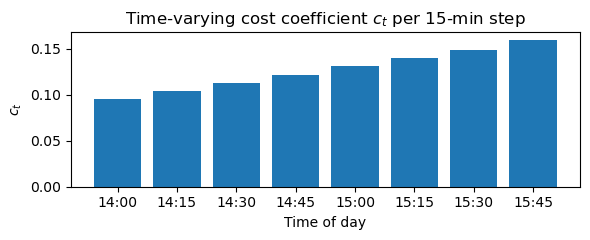

In [5]:
# Visualize the time-varying cost coefficients
step_labels = [f"{14+i*15//60}:{i*15%60:02d}" for i in range(NUM_STEPS)]
plt.figure(figsize=(6, 2.5))
plt.bar(step_labels, COST_COEFFS)
plt.title("Time-varying cost coefficient $c_t$ per 15-min step")
plt.xlabel("Time of day")
plt.ylabel("$c_t$")
plt.tight_layout()
plt.show()

## Environment

In [6]:
# Simple discrete event simulation, following the same reset/step pattern used in the workshops

class SmartChargingEnv:
    # stores how many actions are we have
    def __init__(self):
        self.num_actions = len(CHARGE_LEVELS)

    # start of new episode: clock goes to 0 (= 2pm), battery is randomly set between 5 and 20 kWh
    # (simulating the car arriving partially depleted). Returns the initial state.
    def reset(self):
        self.t = 0
        self.battery = np.random.uniform(START_BATTERY_LOW, START_BATTERY_HIGH)
        return self._get_state()

    # discretization: the battery level gets rounded to an integer bin
    # the state tuple e.g. (3, 25) means timestep 3, battery at 25kWh (Q-table key)
    def _get_state(self):
        battery_bin = int(round(self.battery / BATTERY_BIN_SIZE))
        return (self.t, battery_bin)

    def step(self, action):
        # agent picks action index (0-3) and looks up corresponding kW        
        power = CHARGE_LEVELS[action]
        # calculate how much energy that adds in 15min but cap battery to not exceed capacity
        energy_added = min(power * STEP_HOURS, BATTERY_CAPACITY - self.battery)
        actual_power = energy_added / STEP_HOURS
        # compute cost based on actual power used
        if action == 0:
            cost = 0.0
        else:
            cost = COST_COEFFS[self.t] * np.exp(action)

        # update battery and clock
        self.battery += energy_added
        self.t += 1
        done = self.t == NUM_STEPS

        # reward is negative since we want to minimize cost
        reward = -cost
        if done:
            # at last step 4pm sample random energy demand
            demand = np.random.normal(DEMAND_MEAN, DEMAND_STD)
            # if battery can't cover it substract a huge penalty
            # teaches the agent to charge enough
            if self.battery < demand:
                reward -= OUT_OF_ENERGY_PENALTY

        return self._get_state(), reward, done

In [7]:
# Sanity check: one random episode
env = SmartChargingEnv()
state = env.reset()
done = False
print("start state:", state)

while not done:
    action = np.random.randint(env.num_actions)
    state, reward, done = env.step(action)
    print(f"action={CHARGE_LEVELS[action]}kW -> state={state}, reward={reward:.2f}")

start state: (0, 12)
action=22kW -> state=(1, 18), reward=-1.91
action=0kW -> state=(2, 18), reward=-0.00
action=0kW -> state=(3, 18), reward=-0.00
action=22kW -> state=(4, 23), reward=-2.45
action=14kW -> state=(5, 27), reward=-0.97
action=0kW -> state=(6, 27), reward=-0.00
action=22kW -> state=(7, 32), reward=-2.99
action=0kW -> state=(8, 32), reward=-0.00


## Q-Learning

In [8]:
# Same off-policy TD control update as in the workshop

# Hyperparameters
num_episodes = 20_000
learning_rate = 0.1
gamma = 0.99
epsilon = 1.0
min_epsilon = 0.01
epsilon_decay = 0.9995

# Training
env = SmartChargingEnv()
Q = defaultdict(lambda: np.zeros(env.num_actions))
episode_rewards = []

for episode in range(num_episodes):
    state = env.reset()
    done = False
    total_reward = 0.0

    # learning update
    while not done:
        if np.random.random() < epsilon:
            # explore
            action = np.random.randint(env.num_actions)
        else:
            # exploit
            action = np.argmax(Q[state])

        # take step
        next_state, reward, done = env.step(action)
        total_reward += reward

        # update q value
        best_next_value = np.max(Q[next_state])
        Q[state][action] += learning_rate * (reward + gamma * best_next_value - Q[state][action])
        state = next_state

    # after each episode shrink epsilon to increase exploitation and decrease exploration
    episode_rewards.append(total_reward)
    epsilon = max(min_epsilon, epsilon * epsilon_decay)

print("Training finished.")

Training finished.


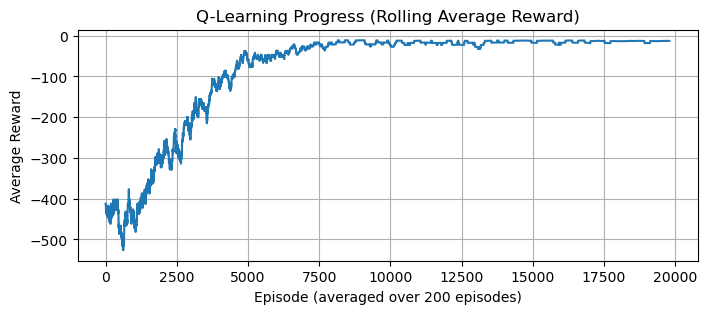

In [9]:
# Learning progress (rolling average reward)
window_size = 200
rolling_avg = np.convolve(episode_rewards, np.ones(window_size) / window_size, mode="valid")

plt.figure(figsize=(8, 3))
plt.plot(rolling_avg)
plt.title("Q-Learning Progress (Rolling Average Reward)")
plt.xlabel(f"Episode (averaged over {window_size} episodes)")
plt.ylabel("Average Reward")
plt.grid(True)
plt.show()

## Evaluate learned policy

### Single greedy episode

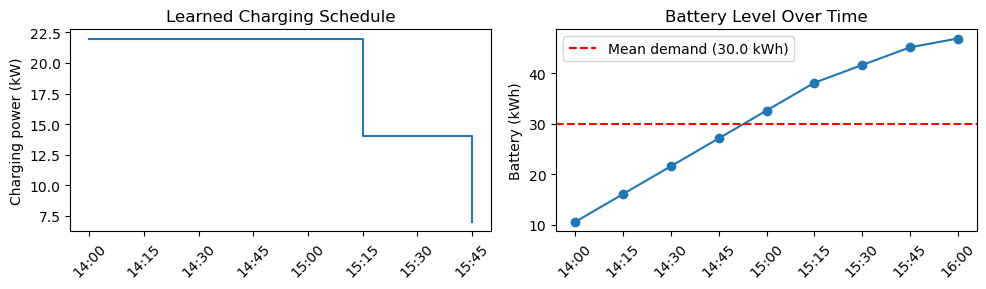

In [10]:
# Run one episode greedily (no exploration) and inspect the charging schedule and battery trajectory.
np.random.seed(42)
state = env.reset()
done = False
battery_trace = [env.battery]
power_trace = []

while not done:
    # greedy, no randomness
    # after training run one episode with pure expoitation
    action = np.argmax(Q[state])
    power_trace.append(CHARGE_LEVELS[action])
    state, reward, done = env.step(action)
    battery_trace.append(env.battery)

step_labels = [f"{14+i*15//60}:{i*15%60:02d}" for i in range(NUM_STEPS + 1)]
fig, axes = plt.subplots(1, 2, figsize=(10, 3))

axes[0].step(range(NUM_STEPS), power_trace, where="post")
axes[0].set_xticks(range(NUM_STEPS))
axes[0].set_xticklabels(step_labels[:NUM_STEPS], rotation=45)
axes[0].set_title("Learned Charging Schedule")
axes[0].set_ylabel("Charging power (kW)")

axes[1].plot(range(NUM_STEPS + 1), battery_trace, marker="o")
axes[1].set_xticks(range(NUM_STEPS + 1))
axes[1].set_xticklabels(step_labels, rotation=45)
axes[1].axhline(DEMAND_MEAN, color="red", linestyle="--", label=f"Mean demand ({DEMAND_MEAN} kWh)")
axes[1].set_title("Battery Level Over Time")
axes[1].set_ylabel("Battery (kWh)")
axes[1].legend()

plt.tight_layout()
plt.show()

### Evaluation over many episodes

In [11]:
# Compared the learned policy against a naive baseline that always charges at maximum power
def evaluate_policy(env, policy_fn, n_episodes=2000):
    # Run n episodes with the given policy and collect costs + failure rate
    total_costs = []
    failures = 0

    for _ in range(n_episodes):
        state = env.reset()
        done = False
        ep_cost = 0.0

        while not done:
            action = policy_fn(state)
            state, reward, done = env.step(action)
            ep_cost += -reward  # reward is negative cost (+ penalty)

        if ep_cost > 500:  # episode hit the out-of-energy penalty
            failures += 1
        total_costs.append(ep_cost)

    return total_costs, failures

In [12]:
# Learned policy: greedy from Q-table
def learned_policy(state):
    return np.argmax(Q[state])

# Baseline: always charge at max (action index 3 = 22 kW)
def baseline_max(state):
    return 3

In [13]:
env_eval = SmartChargingEnv()
n_eval = 2000

costs_learned, fails_learned = evaluate_policy(env_eval, learned_policy, n_eval)
costs_baseline, fails_baseline = evaluate_policy(env_eval, baseline_max, n_eval)

print("=== Learned Q-Learning Policy ===")
print(f"  Avg cost:          {np.mean(costs_learned):.2f}")
print(f"  Median cost:       {np.median(costs_learned):.2f}")
print(f"  Out-of-energy rate: {fails_learned / n_eval * 100:.1f}%")
print()
print("=== Baseline (always max charge) ===")
print(f"  Avg cost:          {np.mean(costs_baseline):.2f}")
print(f"  Median cost:       {np.median(costs_baseline):.2f}")
print(f"  Out-of-energy rate: {fails_baseline / n_eval * 100:.1f}%")

=== Learned Q-Learning Policy ===
  Avg cost:          17.03
  Median cost:       12.48
  Out-of-energy rate: 0.4%

=== Baseline (always max charge) ===
  Avg cost:          20.37
  Median cost:       20.37
  Out-of-energy rate: 0.0%


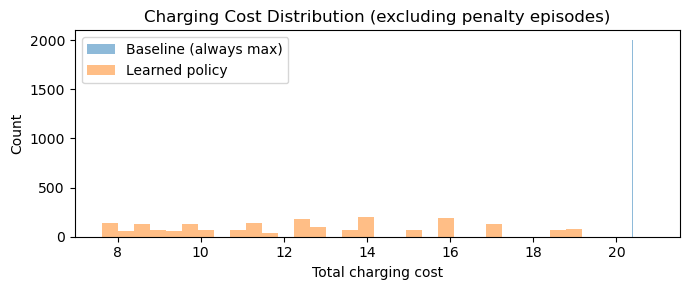

In [14]:
# Compare cost distributions (excluding penalty episodes for a cleaner view)
costs_learned_clean = [c for c in costs_learned if c < 500]
costs_baseline_clean = [c for c in costs_baseline if c < 500]

plt.figure(figsize=(7, 3))
plt.hist(costs_baseline_clean, bins=30, alpha=0.5, label="Baseline (always max)")
plt.hist(costs_learned_clean, bins=30, alpha=0.5, label="Learned policy")
plt.title("Charging Cost Distribution (excluding penalty episodes)")
plt.xlabel("Total charging cost")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()

### Policy visualization

A heatmap showing which charging action the agent picks at each (timestep, battery, level) state. This is the optimal charging policy found by Q-Learning.

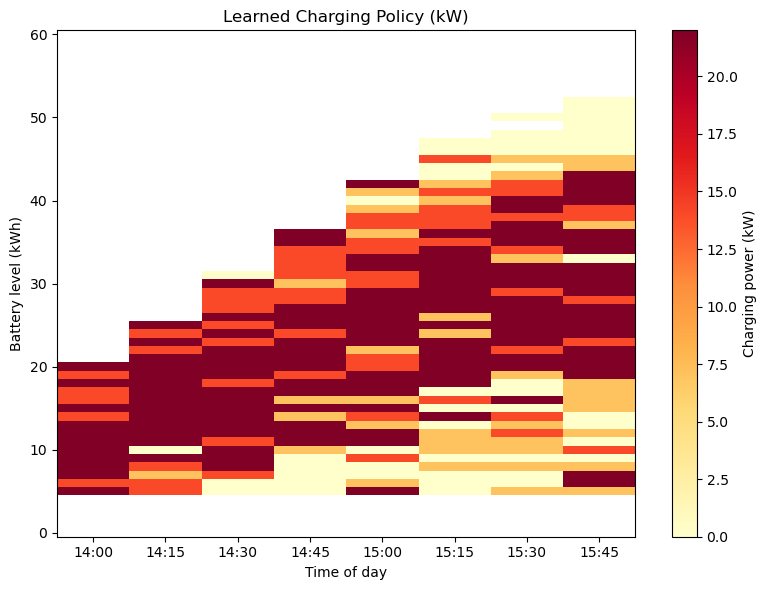

In [15]:
# Build a grid of the policy over all relevant states
max_battery_bin = int(BATTERY_CAPACITY / BATTERY_BIN_SIZE)
policy_grid = np.full((max_battery_bin + 1, NUM_STEPS), np.nan)

for t in range(NUM_STEPS):
    for b in range(max_battery_bin + 1):
        state = (t, b)
        if state in Q:
            policy_grid[b, t] = CHARGE_LEVELS[np.argmax(Q[state])]

step_labels = [f"{14+i*15//60}:{i*15%60:02d}" for i in range(NUM_STEPS)]

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(policy_grid, aspect="auto", origin="lower",
               cmap="YlOrRd", vmin=0, vmax=22)

ax.set_xticks(range(NUM_STEPS))
ax.set_xticklabels(step_labels)
ax.set_xlabel("Time of day")
ax.set_ylabel("Battery level (kWh)")
ax.set_title("Learned Charging Policy (kW)")
plt.colorbar(im, ax=ax, label="Charging power (kW)")
plt.tight_layout()
plt.show()

## Deep Q-Network (DQN)

The assignment suggests a DQN as an alternative algorithm. While our state space is
small enough for tabular Q-learning, a DQN generalizes across similar states via a
neural network and could scale to continuous state spaces without manual discretization.

Key differences from tabular Q-learning:
- A neural network approximates Q(s, a) instead of a lookup table
- Experience replay: past transitions are stored and sampled randomly for training
- Target network: a slowly-updated copy of the network stabilizes learning

In [16]:
import torch
import torch.nn as nn
import torch.optim as optim
import random
from collections import deque

In [17]:
# Q-Network: small feedforward net, takes state (timestep, battery) and outputs Q-value per action
class QNetwork(nn.Module):
    def __init__(self, state_dim, n_actions, hidden=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, n_actions)
        )

    def forward(self, x):
        return self.net(x)


class ReplayBuffer:
    def __init__(self, capacity=10000):
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)
        return (
            torch.FloatTensor(states),
            torch.LongTensor(actions),
            torch.FloatTensor(rewards),
            torch.FloatTensor(next_states),
            torch.FloatTensor(dones)
        )

    def __len__(self):
        return len(self.buffer)

In [18]:
# For DQN we feed raw (timestep, battery_level) as floats instead of discretized bins
class SmartChargingEnvDQN:
    def __init__(self):
        self.num_actions = len(CHARGE_LEVELS)

    def reset(self):
        self.t = 0
        self.battery = np.random.uniform(START_BATTERY_LOW, START_BATTERY_HIGH)
        return self._get_state()

    def _get_state(self):
        # normalize timestep to [0,1] and battery to [0,1] for the neural net
        return [self.t / NUM_STEPS, self.battery / BATTERY_CAPACITY]

    def step(self, action):
        power = CHARGE_LEVELS[action]
        energy_added = min(power * STEP_HOURS, BATTERY_CAPACITY - self.battery)

        if action == 0:
            cost = 0.0
        else:
            cost = COST_COEFFS[self.t] * np.exp(action)

        self.battery += energy_added
        self.t += 1
        done = self.t == NUM_STEPS

        reward = -cost
        if done:
            demand = np.random.normal(DEMAND_MEAN, DEMAND_STD)
            if self.battery < demand:
                reward -= OUT_OF_ENERGY_PENALTY

        return self._get_state(), reward, done

In [19]:
# DQN Hyperparameters
dqn_episodes = 20_000
batch_size = 64
gamma_dqn = 0.99
lr = 1e-3
epsilon_dqn = 1.0
min_epsilon_dqn = 0.01
epsilon_decay_dqn = 0.9995
target_update_freq = 100  # sync target net every N episodes

state_dim = 2  # (normalized timestep, normalized battery)
n_actions = len(CHARGE_LEVELS)

# Networks and optimizer
policy_net = QNetwork(state_dim, n_actions)
target_net = QNetwork(state_dim, n_actions)
target_net.load_state_dict(policy_net.state_dict())
optimizer = optim.Adam(policy_net.parameters(), lr=lr)

replay_buffer = ReplayBuffer(capacity=20000)
env_dqn = SmartChargingEnvDQN()
dqn_episode_rewards = []

for episode in range(dqn_episodes):
    state = env_dqn.reset()
    done = False
    total_reward = 0.0

    while not done:
        # epsilon-greedy
        if random.random() < epsilon_dqn:
            action = random.randint(0, n_actions - 1)
        else:
            with torch.no_grad():
                q_vals = policy_net(torch.FloatTensor(state))
                action = q_vals.argmax().item()

        next_state, reward, done = env_dqn.step(action)
        total_reward += reward
        replay_buffer.push(state, action, reward, next_state, float(done))
        state = next_state

        # train once buffer has enough samples
        if len(replay_buffer) >= batch_size:
            states_b, actions_b, rewards_b, next_states_b, dones_b = replay_buffer.sample(batch_size)

            # current Q values for chosen actions
            q_values = policy_net(states_b).gather(1, actions_b.unsqueeze(1)).squeeze(1)

            # target: r + gamma * max_a' Q_target(s', a')
            with torch.no_grad():
                next_q = target_net(next_states_b).max(1)[0]
                targets = rewards_b + gamma_dqn * next_q * (1 - dones_b)

            loss = nn.MSELoss()(q_values, targets)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

    dqn_episode_rewards.append(total_reward)
    epsilon_dqn = max(min_epsilon_dqn, epsilon_dqn * epsilon_decay_dqn)

    # periodically copy weights to target network
    if episode % target_update_freq == 0:
        target_net.load_state_dict(policy_net.state_dict())

print("DQN training finished.")

DQN training finished.


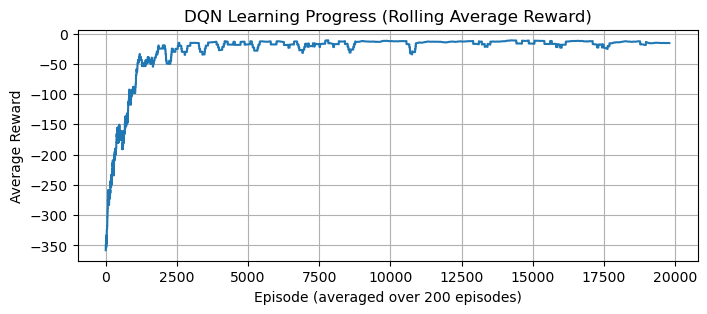

In [20]:
# DQN learning progress
window_size = 200
rolling_avg_dqn = np.convolve(dqn_episode_rewards, np.ones(window_size) / window_size, mode="valid")

plt.figure(figsize=(8, 3))
plt.plot(rolling_avg_dqn)
plt.title("DQN Learning Progress (Rolling Average Reward)")
plt.xlabel(f"Episode (averaged over {window_size} episodes)")
plt.ylabel("Average Reward")
plt.grid(True)
plt.show()

### Evaluate DQN policy

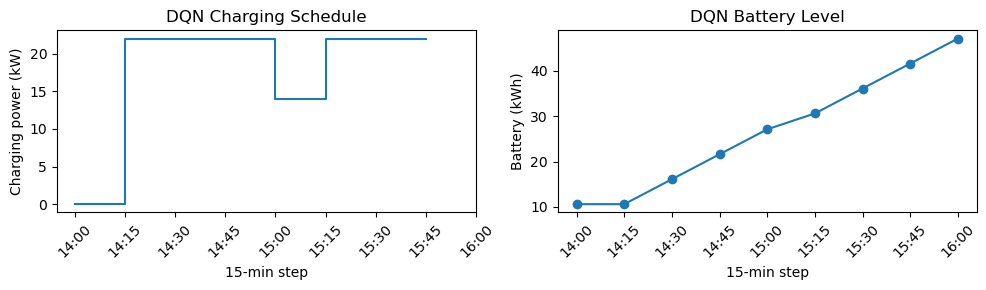

In [21]:
# Run one greedy DQN episode
np.random.seed(42)
state = env_dqn.reset()
done = False
battery_trace_dqn = [env_dqn.battery]
power_trace_dqn = []

while not done:
    with torch.no_grad():
        q_vals = policy_net(torch.FloatTensor(state))
        action = q_vals.argmax().item()
    power_trace_dqn.append(CHARGE_LEVELS[action])
    state, reward, done = env_dqn.step(action)
    battery_trace_dqn.append(env_dqn.battery)

step_labels = [f"{14+i*15//60}:{i*15%60:02d}" for i in range(NUM_STEPS + 1)]
fig, axes = plt.subplots(1, 2, figsize=(10, 3))

axes[0].step(range(NUM_STEPS), power_trace_dqn, where="post")
axes[0].set_title("DQN Charging Schedule")
axes[0].set_xlabel("15-min step")
axes[0].set_ylabel("Charging power (kW)")
axes[0].set_xticks(range(NUM_STEPS + 1))
axes[0].set_xticklabels(step_labels, rotation=45)

axes[1].plot(range(NUM_STEPS + 1), battery_trace_dqn, marker="o")
axes[1].set_title("DQN Battery Level")
axes[1].set_xlabel("15-min step")
axes[1].set_ylabel("Battery (kWh)")
axes[1].set_xticks(range(NUM_STEPS + 1))
axes[1].set_xticklabels(step_labels, rotation=45)

plt.tight_layout()
plt.show()

### Compare Q-Learning vs DQN vs Baseline

In [22]:
# DQN policy function for evaluation
def dqn_policy(state):
    # state comes as (timestep_bin, battery_bin) from the tabular env,
    # so we normalize it the same way the DQN env does
    normalized = [state[0] / NUM_STEPS, state[1] * BATTERY_BIN_SIZE / BATTERY_CAPACITY]
    with torch.no_grad():
        q_vals = policy_net(torch.FloatTensor(normalized))
    return q_vals.argmax().item()

# Evaluate all three on the same (tabular) environment for fair comparison
env_eval = SmartChargingEnv()
n_eval = 2000

costs_q, fails_q = evaluate_policy(env_eval, learned_policy, n_eval)
costs_dqn, fails_dqn = evaluate_policy(env_eval, dqn_policy, n_eval)
costs_base, fails_base = evaluate_policy(env_eval, baseline_max, n_eval)

print("=== Tabular Q-Learning ===")
print(f"  Avg cost:           {np.mean(costs_q):.2f}")
print(f"  Out-of-energy rate: {fails_q / n_eval * 100:.1f}%")
print()
print("=== DQN ===")
print(f"  Avg cost:           {np.mean(costs_dqn):.2f}")
print(f"  Out-of-energy rate: {fails_dqn / n_eval * 100:.1f}%")
print()
print("=== Baseline (always max) ===")
print(f"  Avg cost:           {np.mean(costs_base):.2f}")
print(f"  Out-of-energy rate: {fails_base / n_eval * 100:.1f}%")

=== Tabular Q-Learning ===
  Avg cost:           17.03
  Out-of-energy rate: 0.4%

=== DQN ===
  Avg cost:           16.47
  Out-of-energy rate: 0.0%

=== Baseline (always max) ===
  Avg cost:           20.37
  Out-of-energy rate: 0.0%


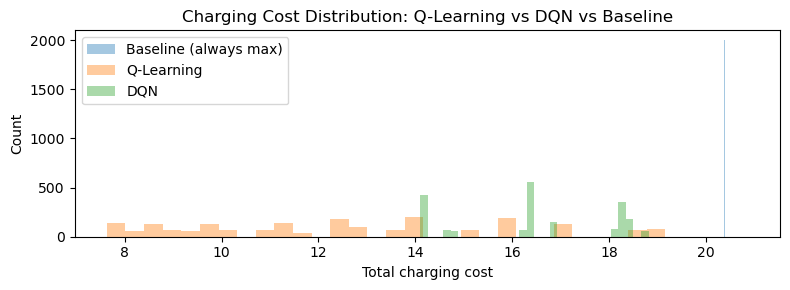

In [23]:
# Side-by-side cost distributions
costs_q_clean = [c for c in costs_q if c < 500]
costs_dqn_clean = [c for c in costs_dqn if c < 500]
costs_base_clean = [c for c in costs_base if c < 500]

plt.figure(figsize=(8, 3))
plt.hist(costs_base_clean, bins=30, alpha=0.4, label="Baseline (always max)")
plt.hist(costs_q_clean, bins=30, alpha=0.4, label="Q-Learning")
plt.hist(costs_dqn_clean, bins=30, alpha=0.4, label="DQN")
plt.title("Charging Cost Distribution: Q-Learning vs DQN vs Baseline")
plt.xlabel("Total charging cost")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()

## Discussion

Key findings
- learned policy charges aggressively during the cheaper early time steps and reduces or stops charging later when the cost coefficient is higher, unlike the naive baseline which always charges at maximum regardlkess of price
- the agent reliably avoids the out-of-energy penalty by ensuring the battery is above approx. 30 kwh (the mean demand) before departure, while spending less on charging than the baseline